In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
figure_dir = "../artifacts/figures"
segment_dir = "../artifacts/segments"

os.makedirs(figure_dir,exist_ok=True)
os.makedirs(segment_dir,exist_ok=True)

In [3]:
file_path = "../data/processed/cleaned_customer_churn.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:")
print(df.shape)
print()
print("First 5 Rows:")
df.head()

Dataset Shape:
(7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"No": 0,"Yes": 1})

print("Churn Values:")
print(df["Churn"].value_counts())

Churn Values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [5]:
df["TenureSegment"] = pd.cut(df["tenure"],
    bins=[-1,12,24,48,60,72],
    labels=["0-12 Months","13-24 Months","25-48 Months","49-60 Months","61-72 Months"])

print("Tenure Segment Distribution:")
print(df["TenureSegment"].value_counts().sort_index())

Tenure Segment Distribution:
TenureSegment
0-12 Months     2186
13-24 Months    1024
25-48 Months    1594
49-60 Months     832
61-72 Months    1407
Name: count, dtype: int64


In [6]:
df["ChargeSegment"] = pd.qcut(df["MonthlyCharges"],q=4,
    labels=["Low","Medium-Low","Medium-High","High"])

print("Monthly Charge Segment Distribution:")
print(df["ChargeSegment"].value_counts())

Monthly Charge Segment Distribution:
ChargeSegment
Medium-Low     1766
Low            1762
High           1758
Medium-High    1757
Name: count, dtype: int64


In [7]:
charge_quartiles = (df["MonthlyCharges"].quantile([0.25,0.50,0.75]))

print("Monthly Charge Quartiles:")
print(charge_quartiles)

Monthly Charge Quartiles:
0.25    35.50
0.50    70.35
0.75    89.85
Name: MonthlyCharges, dtype: float64


In [8]:
def analyze_segment(data,column):
    result = (data.groupby(column,observed=True).agg(
            Total_Customers=("customerID","count"),
            Churned_Customers=("Churn","sum"),
            Churn_Rate=("Churn","mean"),
            Average_Monthly_Charges=("MonthlyCharges","mean"),
            Average_Total_Charges=("TotalCharges","mean")
        ).reset_index())

    result["Churn_Rate"] = (result["Churn_Rate"]* 100).round(2)
    return result


In [9]:
tenure_analysis = analyze_segment(df,"TenureSegment")

print("Tenure Segment Analysis:")
print(tenure_analysis)

Tenure Segment Analysis:
  TenureSegment  Total_Customers  Churned_Customers  Churn_Rate  \
0   0-12 Months             2186               1037       47.44   
1  13-24 Months             1024                294       28.71   
2  25-48 Months             1594                325       20.39   
3  49-60 Months              832                120       14.42   
4  61-72 Months             1407                 93        6.61   

   Average_Monthly_Charges  Average_Total_Charges  
0                56.097781             275.229597  
1                61.357275            1126.257520  
2                65.930552            2390.451913  
3                70.550781            3848.132572  
4                75.952701            5180.669829  


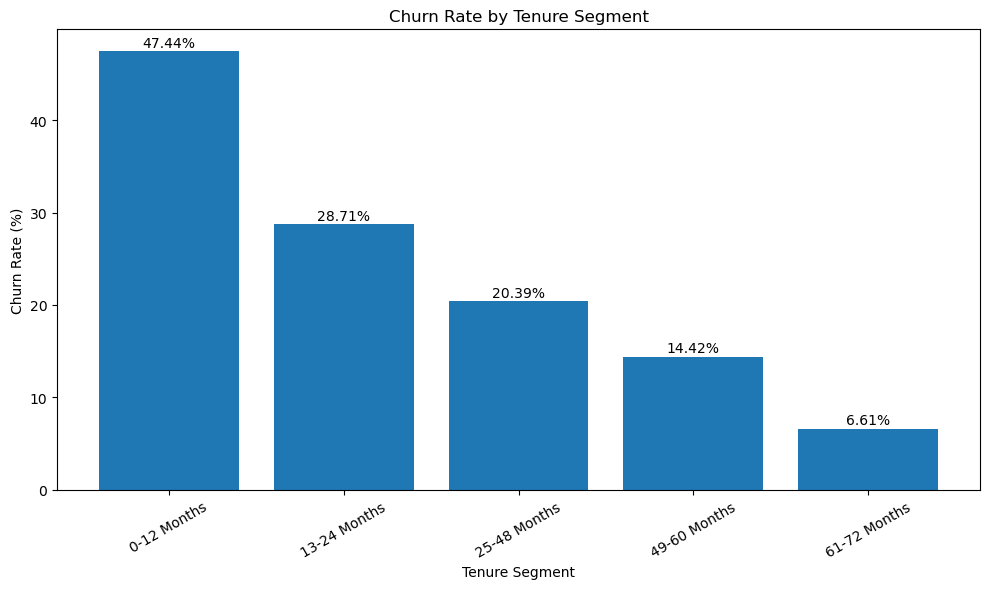

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(tenure_analysis["TenureSegment"].astype(str),tenure_analysis["Churn_Rate"])

plt.title("Churn Rate by Tenure Segment")

plt.xlabel("Tenure Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)

for index, value in enumerate(tenure_analysis["Churn_Rate"]):
    plt.text(index,value + 0.5,f"{value:.2f}%",ha="center")
plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"segmentation_tenure_churn.png"),dpi=300)

plt.show()

In [11]:
charge_analysis = analyze_segment(df,"ChargeSegment")

print(charge_analysis)

  ChargeSegment  Total_Customers  Churned_Customers  Churn_Rate  \
0           Low             1762                198       11.24   
1    Medium-Low             1766                434       24.58   
2   Medium-High             1757                659       37.51   
3          High             1758                578       32.88   

   Average_Monthly_Charges  Average_Total_Charges  
0                22.230306             638.191459  
1                55.729360            1501.747395  
2                80.334861            2401.057598  
3               100.898976            4585.285125  


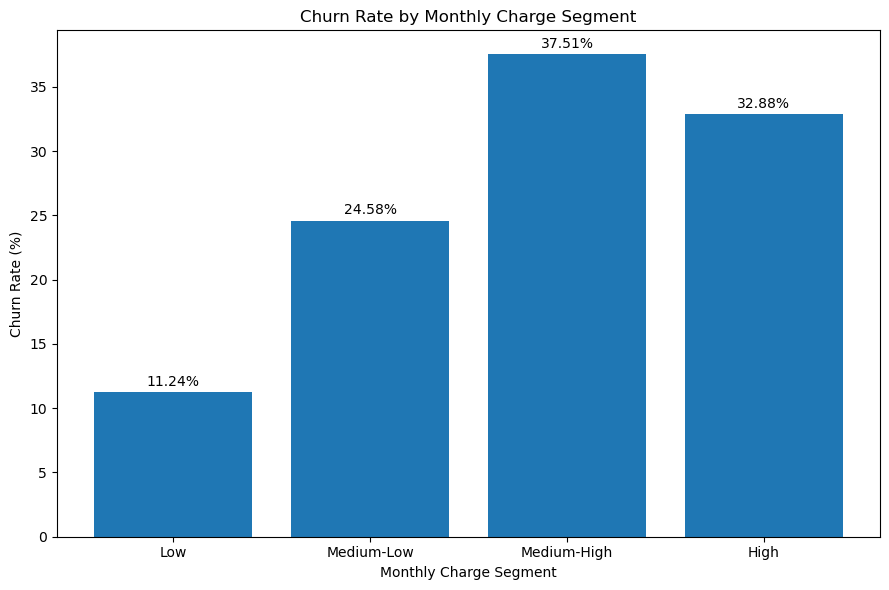

In [12]:
plt.figure(figsize=(9, 6))
plt.bar(charge_analysis["ChargeSegment"].astype(str),charge_analysis["Churn_Rate"])

plt.title("Churn Rate by Monthly Charge Segment")
plt.xlabel("Monthly Charge Segment")
plt.ylabel("Churn Rate (%)")

for index, value in enumerate(charge_analysis["Churn_Rate"]):
    plt.text(index,value + 0.5,f"{value:.2f}%",ha="center")

plt.tight_layout()
plt.savefig(os.path.join(figure_dir,"segmentation_charge_churn.png"),dpi=300)

plt.show()


In [13]:
contract_analysis = analyze_segment(df,"Contract")

contract_analysis = (contract_analysis.sort_values("Churn_Rate",ascending=False))

print("Contract Segment Analysis:")
print(contract_analysis)

Contract Segment Analysis:
         Contract  Total_Customers  Churned_Customers  Churn_Rate  \
0  Month-to-month             3875               1655       42.71   
1        One year             1473                166       11.27   
2        Two year             1695                 48        2.83   

   Average_Monthly_Charges  Average_Total_Charges  
0                66.398490            1369.254581  
1                65.048608            3032.622878  
2                60.770413            3706.934336  


In [14]:
df["CustomerSegment"] = (df["TenureSegment"].astype(str)+ " | "+ df["ChargeSegment"].astype(str)+ " | "+ df["Contract"])

print("Sample Customer Segments:")
print(df[["customerID","TenureSegment","ChargeSegment","Contract","CustomerSegment"]].head(10))

Sample Customer Segments:
   customerID TenureSegment ChargeSegment        Contract  \
0  7590-VHVEG   0-12 Months           Low  Month-to-month   
1  5575-GNVDE  25-48 Months    Medium-Low        One year   
2  3668-QPYBK   0-12 Months    Medium-Low  Month-to-month   
3  7795-CFOCW  25-48 Months    Medium-Low        One year   
4  9237-HQITU   0-12 Months   Medium-High  Month-to-month   
5  9305-CDSKC   0-12 Months          High  Month-to-month   
6  1452-KIOVK  13-24 Months   Medium-High  Month-to-month   
7  6713-OKOMC   0-12 Months           Low  Month-to-month   
8  7892-POOKP  25-48 Months          High  Month-to-month   
9  6388-TABGU  61-72 Months    Medium-Low        One year   

                               CustomerSegment  
0           0-12 Months | Low | Month-to-month  
1         25-48 Months | Medium-Low | One year  
2    0-12 Months | Medium-Low | Month-to-month  
3         25-48 Months | Medium-Low | One year  
4   0-12 Months | Medium-High | Month-to-month  
5       

In [15]:
combined_segment_analysis = (df.groupby(["TenureSegment","ChargeSegment","Contract"],observed=True).agg(
        Total_Customers=("customerID","count"),
        Churned_Customers=("Churn","sum"),
        Churn_Rate=("Churn","mean"),
        Average_Monthly_Charges=("MonthlyCharges","mean"),
        Average_Total_Charges=("TotalCharges","mean")
    ).reset_index())


combined_segment_analysis["Churn_Rate_Percentage"] = (combined_segment_analysis["Churn_Rate"]* 100).round(2)
combined_segment_analysis = (combined_segment_analysis.sort_values("Churn_Rate",ascending=False))

print(combined_segment_analysis.head(20))

   TenureSegment ChargeSegment        Contract  Total_Customers  \
9    0-12 Months          High  Month-to-month              214   
6    0-12 Months   Medium-High  Month-to-month              598   
20  13-24 Months          High  Month-to-month              180   
47  61-72 Months           Low  Month-to-month                2   
3    0-12 Months    Medium-Low  Month-to-month              664   
17  13-24 Months   Medium-High  Month-to-month              245   
32  25-48 Months          High  Month-to-month              291   
29  25-48 Months   Medium-High  Month-to-month              244   
44  49-60 Months          High  Month-to-month              114   
21  13-24 Months          High        One year               12   
10   0-12 Months          High        One year                6   
0    0-12 Months           Low  Month-to-month              518   
56  61-72 Months          High  Month-to-month               71   
14  13-24 Months    Medium-Low  Month-to-month              19

In [16]:
reliable_segments = (combined_segment_analysis[combined_segment_analysis["Total_Customers"] >= 30].copy())

print("Reliable Segments ""(Minimum 30 Customers):")

print(reliable_segments.head(20))


Reliable Segments (Minimum 30 Customers):
   TenureSegment ChargeSegment        Contract  Total_Customers  \
9    0-12 Months          High  Month-to-month              214   
6    0-12 Months   Medium-High  Month-to-month              598   
20  13-24 Months          High  Month-to-month              180   
3    0-12 Months    Medium-Low  Month-to-month              664   
17  13-24 Months   Medium-High  Month-to-month              245   
32  25-48 Months          High  Month-to-month              291   
29  25-48 Months   Medium-High  Month-to-month              244   
44  49-60 Months          High  Month-to-month              114   
0    0-12 Months           Low  Month-to-month              518   
56  61-72 Months          High  Month-to-month               71   
14  13-24 Months    Medium-Low  Month-to-month              198   
41  49-60 Months   Medium-High  Month-to-month               62   
45  49-60 Months          High        One year              139   
33  25-48 Months    

In [17]:
reliable_segments["Segment"] = (reliable_segments["TenureSegment"].astype(str)+ " | "+ reliable_segments["ChargeSegment"].astype(str)+ " | "+ reliable_segments["Contract"])

In [18]:
top_risk_segments = (reliable_segments.head(10).copy())

print("Top 10 High-Churn Segments:")
print(top_risk_segments[["Segment","Total_Customers","Churned_Customers","Churn_Rate_Percentage"]])

Top 10 High-Churn Segments:
                                        Segment  Total_Customers  \
9           0-12 Months | High | Month-to-month              214   
6    0-12 Months | Medium-High | Month-to-month              598   
20         13-24 Months | High | Month-to-month              180   
3     0-12 Months | Medium-Low | Month-to-month              664   
17  13-24 Months | Medium-High | Month-to-month              245   
32         25-48 Months | High | Month-to-month              291   
29  25-48 Months | Medium-High | Month-to-month              244   
44         49-60 Months | High | Month-to-month              114   
0            0-12 Months | Low | Month-to-month              518   
56         61-72 Months | High | Month-to-month               71   

    Churned_Customers  Churn_Rate_Percentage  
9                 165                  77.10  
6                 403                  67.39  
20                101                  56.11  
3                 302              

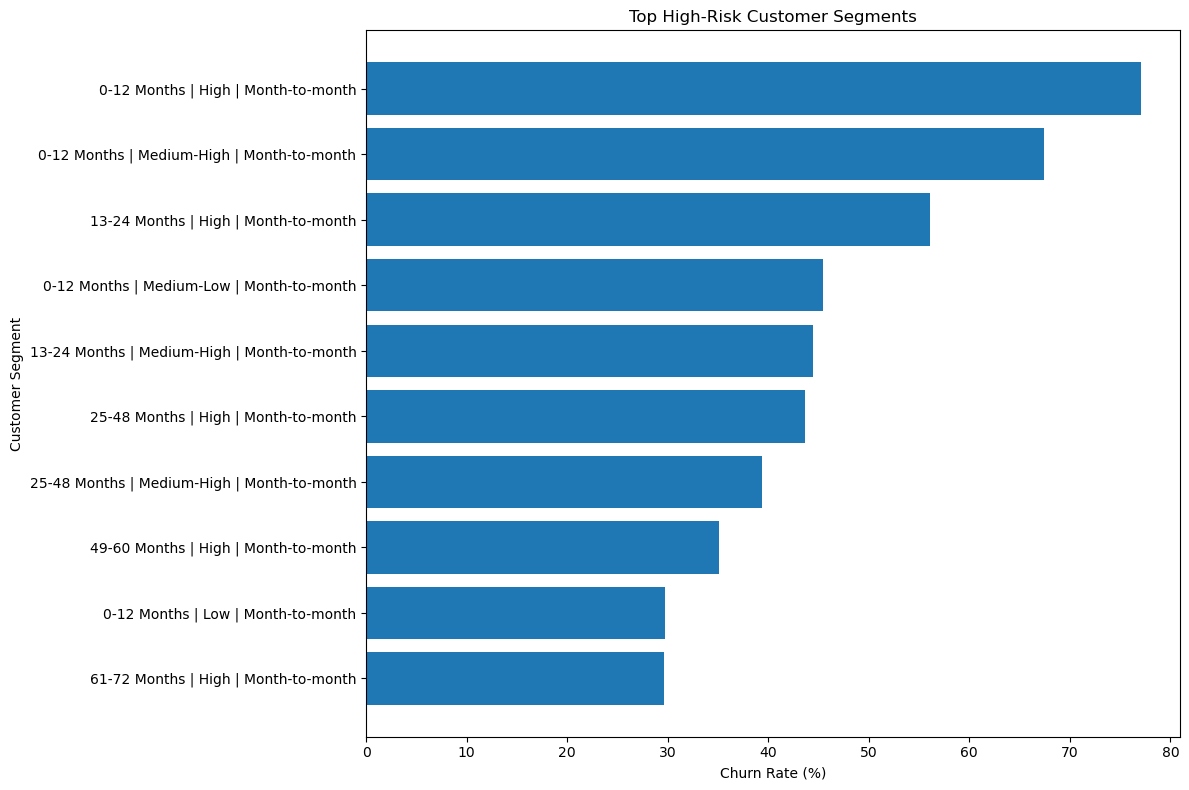

In [19]:
top_risk_plot = (top_risk_segments.sort_values("Churn_Rate_Percentage"))

plt.figure(figsize=(12, 8))
plt.barh(top_risk_plot["Segment"],top_risk_plot["Churn_Rate_Percentage"])

plt.title("Top High-Risk Customer Segments")

plt.xlabel("Churn Rate (%)")

plt.ylabel("Customer Segment")

plt.tight_layout()

plt.savefig(os.path.join(figure_dir,"top_high_risk_segments.png"),dpi=300)

plt.show()


In [20]:
overall_churn_rate = (df["Churn"].mean())

print("Overall Churn Rate:")

print(f"{overall_churn_rate * 100:.2f}%")

Overall Churn Rate:
26.54%


In [21]:
high_risk_threshold = (overall_churn_rate * 1.5)

print("High Risk Threshold:")

print(f"{high_risk_threshold * 100:.2f}%")

High Risk Threshold:
39.81%


In [22]:
def assign_risk_level(churn_rate):
    if churn_rate >= high_risk_threshold:
        return "High Risk"
    elif churn_rate >= overall_churn_rate:
        return "Medium Risk"
    else:
        return "Low Risk"

reliable_segments["Risk_Level"] = (reliable_segments["Churn_Rate"].apply(assign_risk_level))


print("Segment Risk Levels:")
print(reliable_segments[
    ["Segment","Total_Customers","Churn_Rate_Percentage","Risk_Level"]
])



Segment Risk Levels:
                                        Segment  Total_Customers  \
9           0-12 Months | High | Month-to-month              214   
6    0-12 Months | Medium-High | Month-to-month              598   
20         13-24 Months | High | Month-to-month              180   
3     0-12 Months | Medium-Low | Month-to-month              664   
17  13-24 Months | Medium-High | Month-to-month              245   
32         25-48 Months | High | Month-to-month              291   
29  25-48 Months | Medium-High | Month-to-month              244   
44         49-60 Months | High | Month-to-month              114   
0            0-12 Months | Low | Month-to-month              518   
56         61-72 Months | High | Month-to-month               71   
14   13-24 Months | Medium-Low | Month-to-month              198   
41  49-60 Months | Medium-High | Month-to-month               62   
45               49-60 Months | High | One year              139   
33               25-48 Mont

In [23]:
segment_metrics = (combined_segment_analysis[
        ["TenureSegment","ChargeSegment","Contract","Total_Customers","Churn_Rate"]
    ].copy())


segment_metrics = (segment_metrics.rename(columns={"Total_Customers":"SegmentCustomerCount","Churn_Rate":"SegmentChurnRate"}))

In [24]:
df = df.merge(segment_metrics,on=["TenureSegment","ChargeSegment","Contract"],how="left")

In [25]:
df["RiskLevel"] = "Low Risk"

df.loc[df["SegmentChurnRate"]>= overall_churn_rate,"RiskLevel"] = "Medium Risk"

df.loc[df["SegmentChurnRate"]>= high_risk_threshold,"RiskLevel"] = "High Risk"

df.loc[df["SegmentCustomerCount"] < 30,"RiskLevel"] = "Insufficient Segment Data"

In [26]:
high_value_threshold = (df["MonthlyCharges"].quantile(0.75))

print("High Value Monthly Charge Threshold:")

print(round(high_value_threshold,2))

df["HighValueCustomer"] = (df["MonthlyCharges"]>= high_value_threshold)

High Value Monthly Charge Threshold:
89.85


In [27]:
high_value_at_risk = (df[(df["Churn"] == 0) & (df["HighValueCustomer"] == True) & (df["RiskLevel"] == "High Risk")].copy())


In [28]:
high_value_at_risk = (high_value_at_risk.sort_values(["SegmentChurnRate","MonthlyCharges"],ascending=[False,False]))

In [29]:
high_value_at_risk["SegmentChurnRatePercentage"] = (high_value_at_risk["SegmentChurnRate"]* 100).round(2)

print("Number of High-Value High-Risk Active Customers:")

print(len(high_value_at_risk))

print("Top High-Value Customers at Risk:")

print(high_value_at_risk[["customerID","tenure","MonthlyCharges","TotalCharges","Contract","TenureSegment","ChargeSegment","SegmentChurnRatePercentage","RiskLevel"]].head(20))


Number of High-Value High-Risk Active Customers:
294
Top High-Value Customers at Risk:
      customerID  tenure  MonthlyCharges  TotalCharges        Contract  \
1568  3292-PBZEJ      11          111.40       1183.05  Month-to-month   
678   5760-IFJOZ       3          107.95        313.60  Month-to-month   
1719  2081-VEYEH       3          107.95        318.60  Month-to-month   
2387  6734-GMPVK       5          105.30        550.60  Month-to-month   
2582  7145-FEJWU      12          105.30       1275.65  Month-to-month   
3872  2018-PZKMU       9          103.10        970.45  Month-to-month   
6963  9547-ITEFG       9          102.60        897.75  Month-to-month   
5031  8118-TJAFG       9          101.50        906.85  Month-to-month   
3270  4132-KALRO       4          100.85        399.25  Month-to-month   
2530  0722-SVSFK       7          100.40        715.00  Month-to-month   
4952  7379-FNIUJ       2          100.20        198.50  Month-to-month   
2280  2754-SDJRD       8 

In [30]:
monthly_revenue_at_risk = (high_value_at_risk["MonthlyCharges"].sum())

print("Monthly Charges Associated With  High-Value High-Risk Customers:")

print(round(monthly_revenue_at_risk,2))

Monthly Charges Associated With  High-Value High-Risk Customers:
28674.4


In [31]:
high_value_risk_summary = (high_value_at_risk.groupby(
        ["TenureSegment","ChargeSegment","Contract"],observed=True).agg
        (At_Risk_Customers=("customerID","count"),
        Average_Monthly_Charge=("MonthlyCharges","mean"),
        Segment_Churn_Rate=("SegmentChurnRate","first")).reset_index())

high_value_risk_summary["Segment_Churn_Rate"] = (high_value_risk_summary["Segment_Churn_Rate"]* 100).round(2)

high_value_risk_summary = (high_value_risk_summary.sort_values("Segment_Churn_Rate",ascending=False))


print(
    "\nHigh-Value At-Risk "
    "Customer Segment Summary:"
)

print(
    high_value_risk_summary
)



High-Value At-Risk Customer Segment Summary:
  TenureSegment ChargeSegment        Contract  At_Risk_Customers  \
1   0-12 Months          High  Month-to-month                 49   
0   0-12 Months   Medium-High  Month-to-month                  2   
2  13-24 Months          High  Month-to-month                 79   
3  25-48 Months          High  Month-to-month                164   

   Average_Monthly_Charge  Segment_Churn_Rate  
1               95.878571               77.10  
0               89.850000               67.39  
2               96.939241               56.11  
3               98.405183               43.64  


In [32]:
df.to_csv(os.path.join(segment_dir,"segmented_customers.csv"),index=False)

In [33]:
combined_segment_analysis.to_csv(os.path.join(segment_dir,"customer_segment_analysis.csv"),index=False)

In [34]:
high_value_at_risk.to_csv(os.path.join(segment_dir,"high_value_at_risk_customers.csv"),index=False)

In [35]:
high_value_risk_summary.to_csv(os.path.join(segment_dir,"high_value_risk_summary.csv"),index=False)
